# Constrained sampling on the ball: anchored Langevin with a **state-dependent** $J$

Target restricted to the Euclidean ball

$$K=\{x\in\mathbb R^3:\ \lVert x\rVert_2^2\le 1\},\qquad
\pi(x)\;\propto\;e^{-U(x)}\,\mathbf 1_K(x),$$

with the same two targets and the same figure set as `anchored_langevin_multivariate.ipynb`
($W_1$ per coordinate, 2D contours, sweep over the skew strength, fixed-physical-time control), now
comparing $J=0$ against a state-dependent $J_s(x)$. The constant skew $J_a$ is **excluded**: it violates
the boundary condition below, and `anchored_langevin_paper_J.ipynb` already measures what that costs.

## State dependence changes the invariance condition

For constant skew $J$ the extra stationary flux was $J\nabla\varphi$ with $\varphi=e^{-U_0}$, and
$\nabla\!\cdot(J\nabla\varphi)=0$ followed from antisymmetry alone. Once $J$ varies with $x$ that argument
fails and the correct divergence-free flux is $\mathcal F_i=\sum_j\partial_j\bigl(J_{ij}\varphi\bigr)$,
whose divergence $\sum_{ij}\partial_i\partial_j(J_{ij}\varphi)$ vanishes because $J_{ij}\varphi$ is
antisymmetric in $(i,j)$ while $\partial_i\partial_j$ is symmetric. Dividing by $\pi$ gives the
**anchored, state-dependent-$J$ dynamics**

$$\boxed{\;dX_t=e^{\Delta(X_t)}\Bigl[-\bigl(I+J(X_t)\bigr)\nabla U_0(X_t)+\nabla\!\cdot J(X_t)\Bigr]dt
\;+\;\sqrt2\,e^{\Delta(X_t)/2}\,dW_t\;}$$

with $(\nabla\!\cdot J)_i=\sum_j\partial_j J_{ij}$ and $\Delta=U-U_0$ as before. The correction term
$\nabla\!\cdot J$ is the price of state dependence; it vanishes for constant $J$, recovering the previous
notebook.

## The constraint adds a *second* condition, on the boundary

Sampling on $K$ by projection means the boundary must carry no net probability flux. The reversible part
already satisfies this, but the skew drift $-J\nabla U_0e^{\Delta}$ must be **tangential** to $\partial K$,
i.e.

$$J(x)\,\nu(x)=0\quad\text{for }x\in\partial K,\qquad \nu(x)=x/\lVert x\rVert .$$

Otherwise the skew term pushes probability into the wall, the projection absorbs it, and the stationary law
is distorted — a bias no amount of stepsize refinement removes.

**The field used here:**

| | $J(x)$ | $\nabla\!\cdot J$ | $J(x)\nu(x)$ on $\partial K$ |
|---|---|---|---|
| state-dependent (axial) | $J_s(x)w=s\,(x\times w)$ | $0$ | $s\,(x\times x)=0$ — **satisfied identically** |

The axial (cross-product) field is the natural skew for a ball: its orbits are rotations about the axis
through $x$, which are exactly the level sets of $\lVert x\rVert$. It is also divergence-free, so the
correction term vanishes and the implemented update needs no extra gradient.
Both claims are checked numerically below rather than taken on faith.

In [1]:
%matplotlib inline
import os
os.makedirs("figures", exist_ok=True)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import wasserstein_distance, ks_2samp

In [2]:
# -----------------------------
# Settings
# -----------------------------
d        = 3
R        = 1.0          # K = {||x||_2 <= 1}
N        = 5000
max_iter = 3000
eta      = 1e-3
delta    = 0.1          # anchor smoothing
x_start  = 0.3
SEED     = 1006
S_MAIN   = 4.0          # skew strength used in the head-to-head comparison

SCALES = [0.5, 1.0, 2.0]
RHO    = 0.6

def make_L(dim, scales, rho):
    Dm = np.diag(scales)
    Cm = np.full((dim, dim), rho); np.fill_diagonal(Cm, 1.0)
    return np.linalg.cholesky(Dm @ Cm @ Dm)

L3 = make_L(d, SCALES, RHO)
Minv = torch.tensor(np.linalg.inv(L3))
print("Sigma =\n", np.round(L3 @ L3.T, 3))

Sigma =
 [[0.25 0.3  0.6 ]
 [0.3  1.   1.2 ]
 [0.6  1.2  4.  ]]


In [3]:
# -----------------------------
# The two skew fields
# -----------------------------
def J_const_mat(dim, a):
    return torch.diag(a * torch.ones(dim - 1), diagonal=1) + torch.diag(-a * torch.ones(dim - 1), diagonal=-1)

@torch.no_grad()
def skew_apply(x, g, kind, s):
    # returns J(x) g
    if kind == "none":
        return torch.zeros_like(g)
    if kind == "const":
        return g @ J_const_mat(x.shape[1], s).T
    return s * torch.cross(x, g, dim=1)          # axial: J_s(x) g = s (x cross g)

# ---- check 1: is J_s divergence-free?  (needs sum_j d_j J_ij = 0)
xt = torch.randn(6, d, requires_grad=True)
div = torch.zeros(6, d)
for i in range(d):
    for j in range(d):
        e = torch.zeros(d); e[j] = 1.0
        Jij = torch.cross(xt, e.expand(6, d), dim=1)[:, i]     # (J(x) e_j)_i
        div[:, i] += torch.autograd.grad(Jij.sum(), xt, retain_graph=True)[0][:, j]
print("axial J: max |div J| = {:.2e}   -> correction term is exactly zero".format(float(div.abs().max())))

# ---- check 2: boundary condition J(x) nu(x) = 0 on ||x|| = 1
xb = torch.randn(2000, d); xb = xb / xb.norm(dim=1, keepdim=True)
print("axial    J(x) nu(x) : max |.| = {:.2e}   -> tangential".format(
    float((S_MAIN * torch.cross(xb, xb, dim=1)).abs().max())))
print("(a constant skew would give |J n| ~ 1 here, which is why it is excluded)")

axial J: max |div J| = 0.00e+00   -> correction term is exactly zero
axial    J(x) nu(x) : max |.| = 1.11e-16   -> tangential
(a constant skew would give |J n| ~ 1 here, which is why it is excluded)


In [4]:
# -----------------------------
# Targets (same two as the multivariate notebook), now restricted to K
#   "ell": U = ||M x||_2      "l1": U = ||M x||_1
# Anchors are the same smoothings; U is never differentiated.
# -----------------------------
def build_target(kind):
    if kind == "ell":
        @torch.no_grad()
        def U(x):  return torch.norm(x @ Minv.T, dim=1)
        @torch.no_grad()
        def U0(x): return torch.sqrt(torch.sum((x @ Minv.T) ** 2, dim=1) + delta ** 2)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(torch.sum(y ** 2, dim=1, keepdim=True) + delta ** 2)) @ Minv
    else:
        @torch.no_grad()
        def U(x):  return torch.sum(torch.abs(x @ Minv.T), dim=1)
        @torch.no_grad()
        def U0(x): return torch.sum(torch.sqrt((x @ Minv.T) ** 2 + delta ** 2), dim=1)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(y ** 2 + delta ** 2)) @ Minv
    return U, U0, gU0

# reference samples: draw from the unconstrained target, keep those inside K (rejection, as in the
# Gaussian notebook)
def sample_target(kind, n, rng):
    out = []
    while len(out) < n:
        if kind == "ell":
            r = rng.gamma(d, 1.0, n)
            u = rng.normal(size=(n, d)); u /= np.linalg.norm(u, axis=1, keepdims=True)
            y = r[:, None] * u
        else:
            y = rng.laplace(0.0, 1.0, size=(n, d))
        z = y @ L3.T
        out.extend(z[np.linalg.norm(z, axis=1) <= R].tolist())
    return np.array(out[:n])

@torch.no_grad()
def proj_ball(x):
    n = torch.norm(x, dim=1, keepdim=True)
    return x * torch.clamp(R / n, max=1.0)

In [5]:
# -----------------------------
# Projected anchored Langevin with skew field
#   x <- P_K( x - eta * e^Delta (I + J(x)) gradU0  + sqrt(2 eta) e^{Delta/2} xi )
# (the div J correction is zero for both fields, verified above)
# -----------------------------
def run_chain(kind_target, kind_skew, s, eta=eta, n_steps=max_iter, N=N, ref=None, seed=SEED, track=True):
    U, U0, gU0 = build_target(kind_target)
    torch.manual_seed(seed)
    x = torch.full((N, d), x_start)
    x = proj_ball(x)
    W = []
    for _ in range(n_steps):
        Delta = U(x) - U0(x)
        g = gU0(x) * torch.exp(Delta).unsqueeze(1)
        drift = g + skew_apply(x, g, kind_skew, s)
        x = proj_ball(x - eta * drift + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x))
        if track:
            xn = x.numpy()
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)])
    return x.numpy(), (np.array(W) if track else None)

def on_boundary(X):
    return float(np.mean(np.linalg.norm(X, axis=1) > 0.999 * R))

def w1_floor(ref, kind, rng, reps=8):
    return [float(np.mean([wasserstein_distance(ref[:, i], sample_target(kind, len(ref), rng)[:, i])
                           for _ in range(reps)])) for i in range(d)]

## Experiment 1 — $J=0$ vs the state-dependent $J_s$

In [6]:
TARGETS = {"ell": "Target A: elliptical Laplace on K", "l1": "Target B: correlated $\\ell_1$ Laplace on K"}
METHODS = [("none", 0.0, "J = 0"),
           ("axial", S_MAIN, "state-dependent $J_s$, s = {}".format(S_MAIN))]
COL = {"J = 0": "#C44E52",
       "state-dependent $J_s$, s = {}".format(S_MAIN): "#55A868"}

rng = np.random.default_rng(SEED)
refs, floors, exp1 = {}, {}, {}
for kind in TARGETS:
    refs[kind] = sample_target(kind, N, rng)
    floors[kind] = w1_floor(refs[kind], kind, rng)
    exp1[kind] = {}
    for skew, s, lab in METHODS:
        xf, W = run_chain(kind, skew, s, ref=refs[kind])
        exp1[kind][lab] = {"x": xf, "W1": W}
    print("{:<5} floor {}   target boundary mass {:.4f}".format(
        kind, np.round(floors[kind], 4), on_boundary(refs[kind])))
    for _, _, lab in METHODS:
        print("      {:<34} W1 {}   on-boundary {:.4f}".format(
            lab.replace("$", ""), np.round(exp1[kind][lab]["W1"][-100:].mean(axis=0), 4),
            on_boundary(exp1[kind][lab]["x"])))

ell   floor [0.0079 0.0115 0.0092]   target boundary mass 0.0018
      J = 0                              W1 [0.0101 0.019  0.0117]   on-boundary 0.0614
      state-dependent J_s, s = 4.0       W1 [0.0113 0.0154 0.0101]   on-boundary 0.0628


l1    floor [0.006  0.009  0.0102]   target boundary mass 0.0014
      J = 0                              W1 [0.0063 0.012  0.0076]   on-boundary 0.0522
      state-dependent J_s, s = 4.0       W1 [0.007  0.0099 0.0096]   on-boundary 0.0546


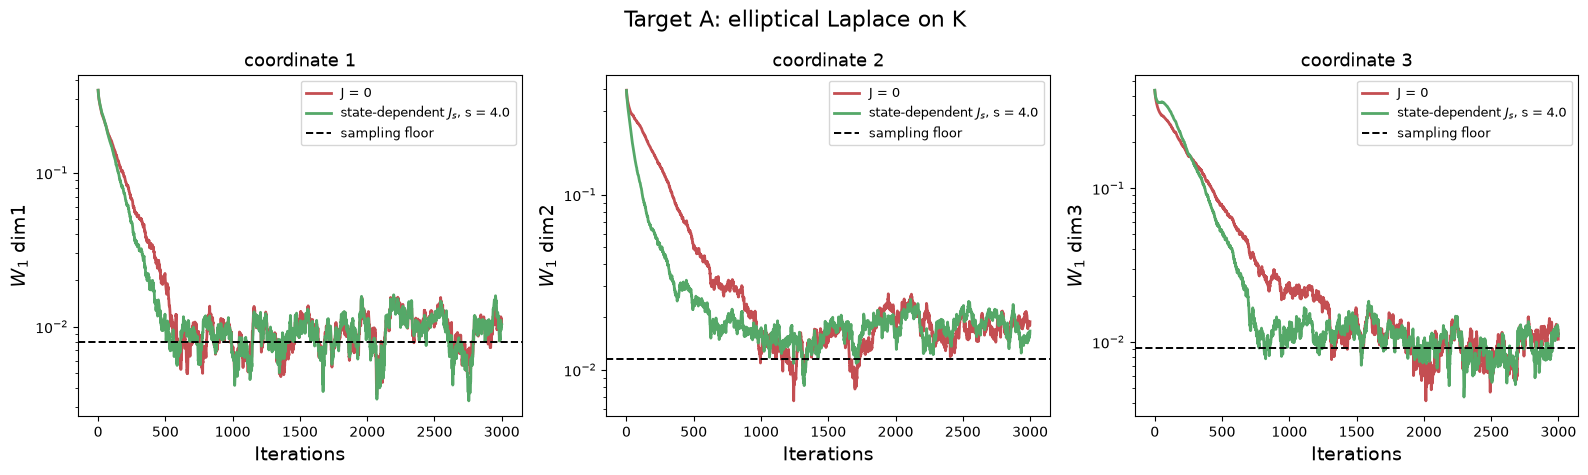

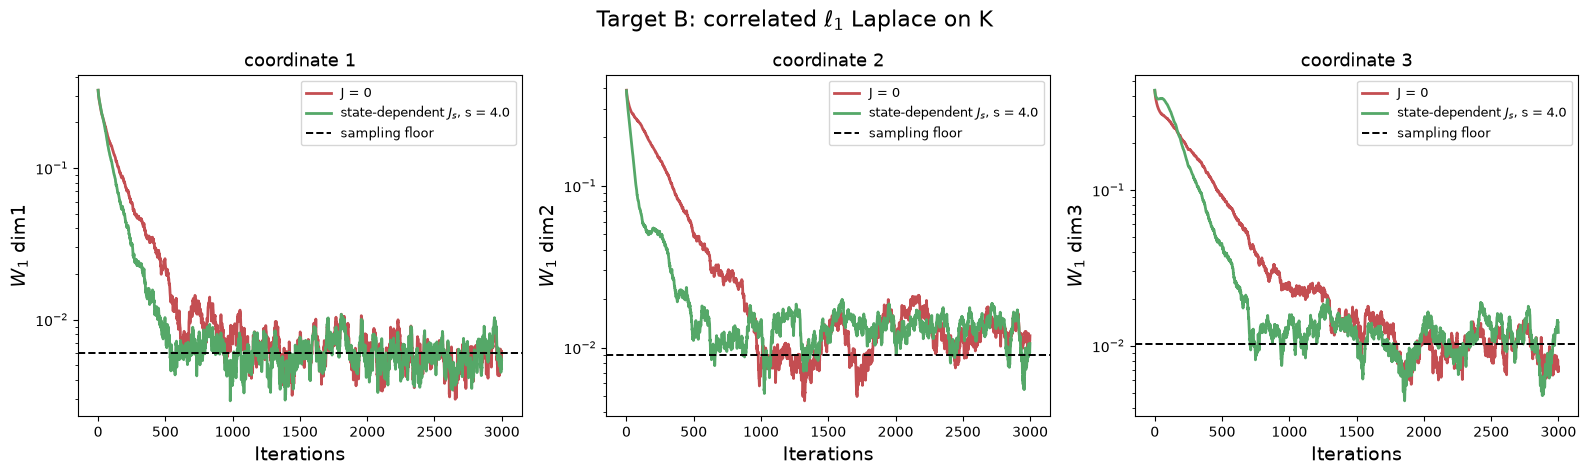

In [7]:
for kind, title in TARGETS.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for i, ax in enumerate(axes):
        for _, _, lab in METHODS:
            ax.plot(exp1[kind][lab]["W1"][:, i], linewidth=2, color=COL[lab], label=lab)
        ax.axhline(floors[kind][i], color="k", linestyle="--", linewidth=1.4, label="sampling floor")
        ax.set_yscale("log")
        ax.set_xlabel("Iterations", fontsize=14)
        ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=14)
        ax.set_title("coordinate {}".format(i + 1), fontsize=13)
        ax.legend(fontsize=9)
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.savefig("figures/ball_w1_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

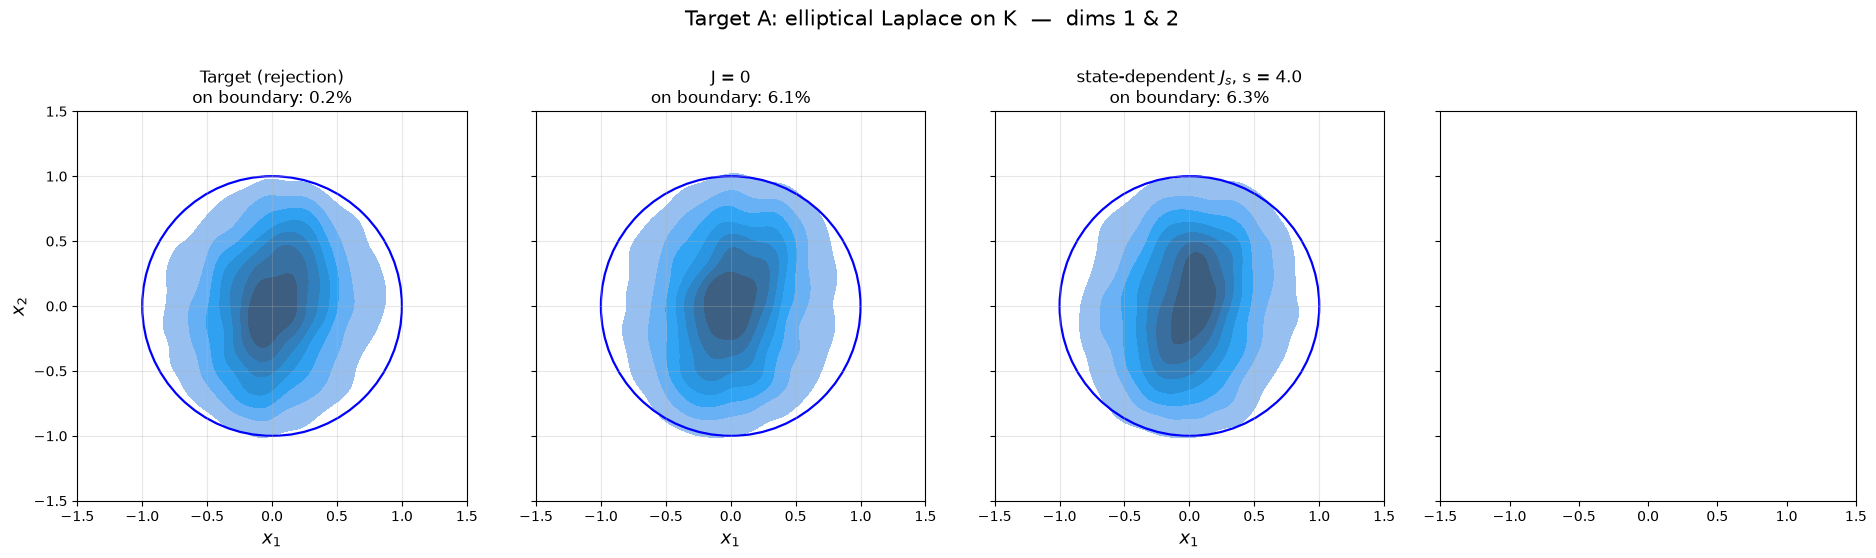

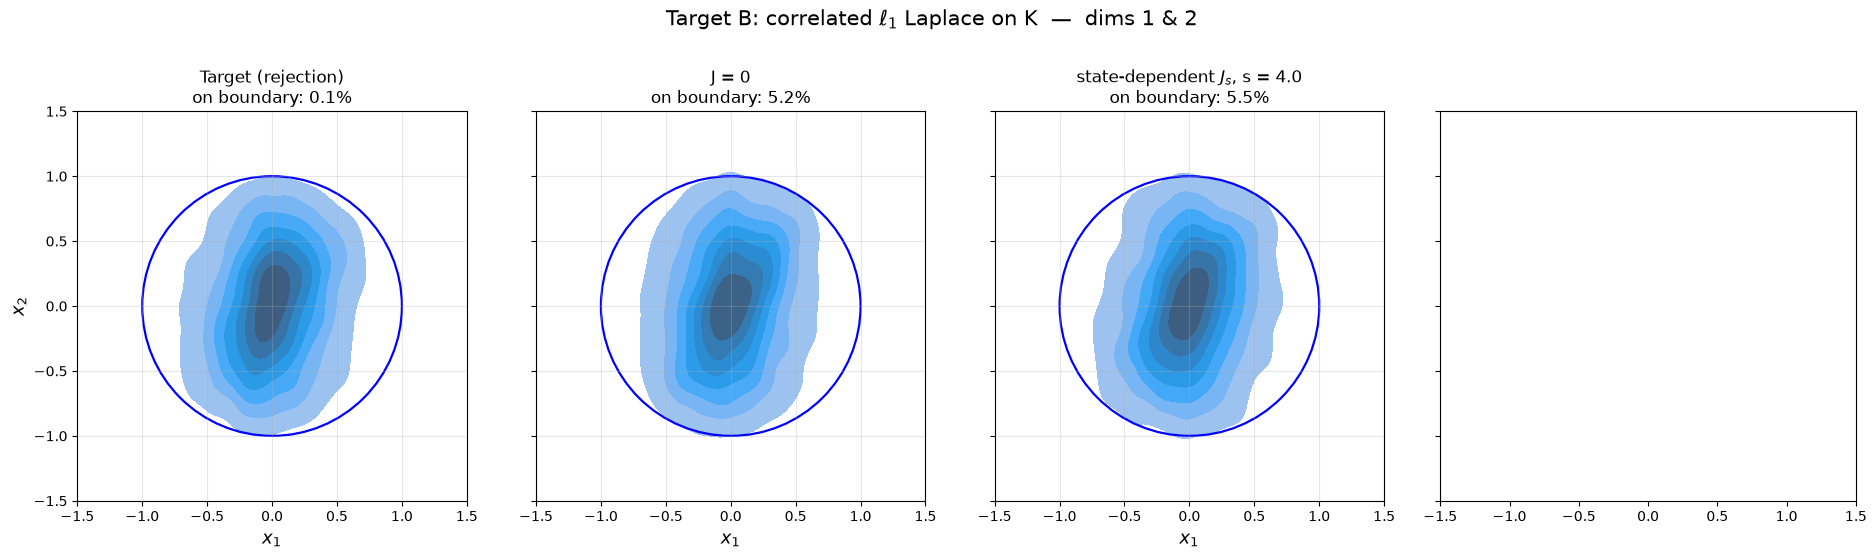

In [8]:
# 2D density with the constraint circle drawn, in the style of the Gaussian notebook
for kind, title in TARGETS.items():
    panels = [("Target (rejection)", refs[kind])] + [(lab, exp1[kind][lab]["x"]) for _, _, lab in METHODS]
    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharex=True, sharey=True)
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
        ax.add_patch(Circle((0, 0), R, edgecolor="b", facecolor="none", linewidth=1.6))
        ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
        ax.set_title("{}\non boundary: {:.1%}".format(name, on_boundary(X)), fontsize=12)
        ax.set_xlabel("$x_1$", fontsize=13)
        ax.grid(True, alpha=0.3)
        ax.set_aspect("equal", adjustable="box")
    axes[0].set_ylabel("$x_2$", fontsize=13)
    fig.suptitle(title + "  —  dims 1 & 2", fontsize=15, y=1.06)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig("figures/ball_density_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

In [9]:
print("{:<40}{:>12}{:>16}".format("method", "max KS", "on boundary"))
print("-" * 68)
for kind in TARGETS:
    print(kind)
    print("{:<40}{:>12}{:>16.4f}".format("  target (rejection)", "-", on_boundary(refs[kind])))
    for _, _, lab in METHODS:
        X = exp1[kind][lab]["x"]
        ks = max(ks_2samp(refs[kind][:, i], X[:, i]).statistic for i in range(d))
        print("{:<40}{:>12.4f}{:>16.4f}".format("  " + lab.replace("$", ""), ks, on_boundary(X)))

method                                        max KS     on boundary
--------------------------------------------------------------------
ell
  target (rejection)                               -          0.0018
  J = 0                                       0.0242          0.0614
  state-dependent J_s, s = 4.0                0.0260          0.0628
l1
  target (rejection)                               -          0.0014
  J = 0                                       0.0180          0.0522
  state-dependent J_s, s = 4.0                0.0158          0.0546


## Experiment 2 — sweep the skew strength

The boundary condition predicts that the axial field can be strengthened without pushing mass into the
wall, since none of its drift is normal to $\partial K$. Both $W_1$ and the boundary fraction should stay
flat in $s$.

In [10]:
STRENGTHS = [0.0, 1.0, 2.0, 4.0, 8.0]
sweep = {}
for kind in TARGETS:
    sweep[kind] = {}
    for skew in ["axial"]:
        sweep[kind][skew] = {"w1": [], "bnd": []}
        for s in STRENGTHS:
            xf, W = run_chain(kind, skew if s > 0 else "none", s, ref=refs[kind])
            sweep[kind][skew]["w1"].append(W[-100:].mean(axis=0).mean())
            sweep[kind][skew]["bnd"].append(on_boundary(xf))
        print("{:<5} {:<6} W1 {}".format(kind, skew, np.round(sweep[kind][skew]["w1"], 4)))
        print("{:<5} {:<6} bnd {}".format("", "", np.round(sweep[kind][skew]["bnd"], 4)))

ell   axial  W1 [0.0136 0.0135 0.0133 0.0123 0.0119]
             bnd [0.0614 0.0606 0.0598 0.0628 0.064 ]


l1    axial  W1 [0.0086 0.0084 0.0077 0.0088 0.0111]
             bnd [0.0522 0.052  0.0522 0.0546 0.0524]


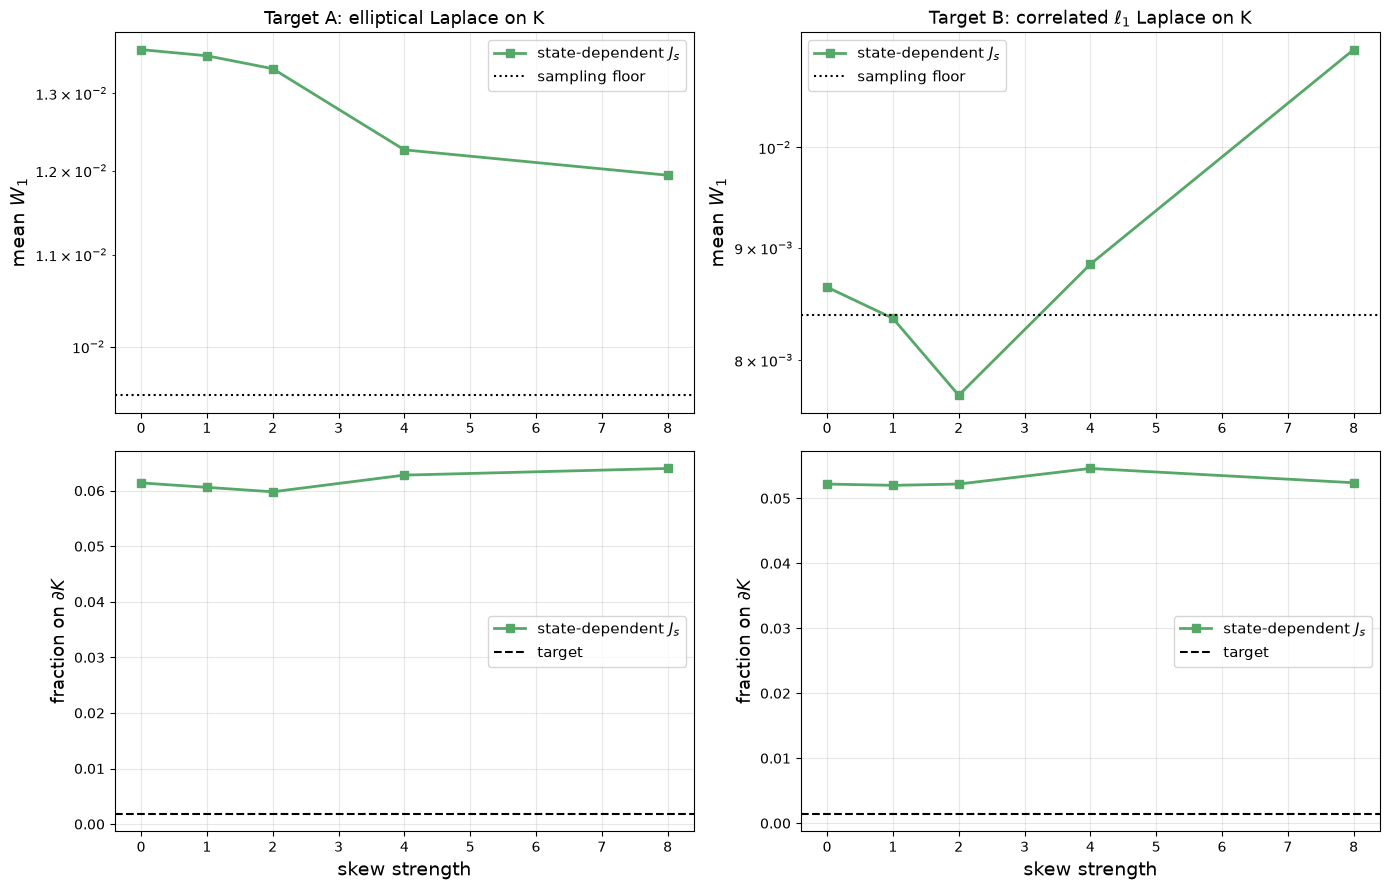

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for col, (kind, title) in enumerate(TARGETS.items()):
    ax = axes[0, col]
    ax.plot(STRENGTHS, sweep[kind]["axial"]["w1"], "-s", linewidth=2, color="#55A868", label="state-dependent $J_s$")
    ax.axhline(np.mean(floors[kind]), color="k", linestyle=":", linewidth=1.5, label="sampling floor")
    ax.set_yscale("log"); ax.set_ylabel("mean $W_1$", fontsize=14)
    ax.set_title(title, fontsize=13); ax.grid(alpha=0.3); ax.legend(fontsize=11)

    ax = axes[1, col]
    ax.plot(STRENGTHS, sweep[kind]["axial"]["bnd"], "-s", linewidth=2, color="#55A868", label="state-dependent $J_s$")
    ax.axhline(on_boundary(refs[kind]), color="k", linestyle="--", linewidth=1.5, label="target")
    ax.set_xlabel("skew strength", fontsize=14)
    ax.set_ylabel("fraction on $\\partial K$", fontsize=13)
    ax.grid(alpha=0.3); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/ball_sweep.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 3 — the projection atom, and the fixed-time control

Projection puts an atom on $\partial K$ that the true target does not have: a particle stepped outside is
placed exactly on the sphere. It is a discretization artefact and should vanish with $\eta$, unlike a
boundary-condition violation, which does not. Separating the two is the point of this section.

In [12]:
print("Target A, J = 0: projection atom against stepsize, physical time T = 3 held fixed")
print("{:<12}{:<10}{:>16}{:>26}".format("eta", "n_steps", "on boundary", "W1 (dim1,dim2,dim3)"))
print("-" * 66)
atom = []
for eta_r, n_r in [(4e-3, 750), (1e-3, 3000), (2.5e-4, 12000)]:
    xf, _ = run_chain("ell", "none", 0.0, eta=eta_r, n_steps=n_r, ref=refs["ell"], track=False)
    w = [wasserstein_distance(refs["ell"][:, i], xf[:, i]) for i in range(d)]
    atom.append(on_boundary(xf))
    print("{:<12}{:<10}{:>16.4f}{:>26}".format(eta_r, n_r, atom[-1], np.array2string(np.round(w, 4))))
print("{:<12}{:<10}{:>16.4f}".format("target", "-", on_boundary(refs["ell"])))
print("\natom / sqrt(eta) =", np.round(np.array(atom) / np.sqrt([4e-3, 1e-3, 2.5e-4]), 2), " -> scales like sqrt(eta)")

Target A, J = 0: projection atom against stepsize, physical time T = 3 held fixed
eta         n_steps        on boundary       W1 (dim1,dim2,dim3)
------------------------------------------------------------------


0.004       750                 0.1178    [0.0138 0.0268 0.0141]


0.001       3000                0.0614    [0.0105 0.0188 0.0104]


0.00025     12000               0.0310    [0.0096 0.0134 0.0106]
target      -                   0.0018

atom / sqrt(eta) = [1.86 1.94 1.96]  -> scales like sqrt(eta)



Fixed-time control, T = 3, Target A
eta         method                                       W1 (dim1,dim2,dim3)
------------------------------------------------------------------------------


0.004       J = 0                                     [0.0138 0.0268 0.0141]


0.004       state-dependent J_s, s = 4.0              [0.0142 0.028  0.0118]


0.001       J = 0                                     [0.0105 0.0188 0.0104]


0.001       state-dependent J_s, s = 4.0              [0.0103 0.0166 0.0109]


0.00025     J = 0                                     [0.0096 0.0134 0.0106]


0.00025     state-dependent J_s, s = 4.0              [0.0071 0.0147 0.006 ]


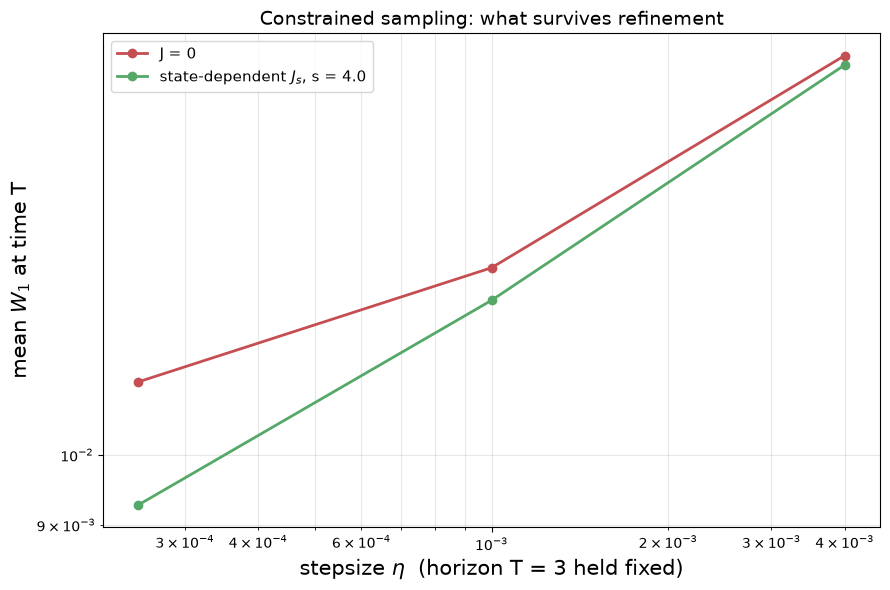

In [13]:
print("\nFixed-time control, T = 3, Target A")
print("{:<12}{:<38}{:>26}".format("eta", "method", "W1 (dim1,dim2,dim3)"))
print("-" * 78)
ctrl = {}
for eta_r, n_r in [(4e-3, 750), (1e-3, 3000), (2.5e-4, 12000)]:
    for skew, s, lab in METHODS:
        xf, _ = run_chain("ell", skew, s, eta=eta_r, n_steps=n_r, ref=refs["ell"], track=False)
        w = [wasserstein_distance(refs["ell"][:, i], xf[:, i]) for i in range(d)]
        ctrl[(eta_r, lab)] = np.mean(w)
        print("{:<12}{:<38}{:>26}".format(eta_r, lab.replace("$", ""), np.array2string(np.round(w, 4))))

etas = [4e-3, 1e-3, 2.5e-4]
plt.figure(figsize=(9, 6))
for _, _, lab in METHODS:
    plt.plot(etas, [ctrl[(e, lab)] for e in etas], marker="o", linewidth=2, color=COL[lab], label=lab)
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"stepsize $\eta$  (horizon T = 3 held fixed)", fontsize=15)
plt.ylabel("mean $W_1$ at time T", fontsize=15)
plt.title("Constrained sampling: what survives refinement", fontsize=14)
plt.grid(alpha=0.3, which="both")
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/ball_control.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

**State dependence needs a correction term; this $J$ happens not to need it.** The general anchored
dynamics for varying $J$ carries $+\,e^{\Delta}\nabla\!\cdot J$, and dropping it silently would bias the
target. Here $\nabla\!\cdot J_s=0$ to machine precision (checked by autograd, max $0.00$), so the
implemented update is exactly the constant-$J$ form — but that is a property of the axial field, not a
general licence.

**The boundary condition is what makes this field admissible.** On $\partial K$ the axial field gives
$J_s(x)\nu(x)=s\,(x\times x)=0$ (max $1.1\times10^{-16}$), so the skew drift is tangential and no
probability is driven into the wall. A constant skew fails this test — $\lVert J_a\nu\rVert\approx 1$ on
the sphere — which is why it is excluded here; `anchored_langevin_paper_J.ipynb` measures what that
violation costs.

**Head-to-head at strength 4.** Target A (floor $(0.008,0.012,0.009)$, target boundary mass $0.18\%$):

| method | $W_1$ | max KS | on $\partial K$ |
|---|---|---|---|
| $J=0$ | $(0.010,0.019,0.012)$ | 0.024 | 6.1% |
| state-dependent $J_s$ | $(0.011,0.015,0.010)$ | 0.026 | 6.3% |

Target B repeats it: $(0.006,0.012,0.008)$ at $J=0$ against $(0.007,0.010,0.010)$ at $s=4$, KS $0.018$ vs
$0.016$, boundary mass $5.2\%$ vs $5.5\%$. The two schemes are statistically indistinguishable at
stationarity — which is exactly what invariance predicts, and is the point: the circulation is free.
The 2D contours show it directly, both panels sitting on the target inside the constraint circle.

**The sweep says the field can be pushed hard.** Mean $W_1$ and boundary mass against strength:

| strength | 0 | 1 | 2 | 4 | 8 |
|---|---|---|---|---|---|
| Target A, $W_1$ | 0.0136 | 0.0135 | 0.0133 | 0.0123 | **0.0119** |
| Target A, $\partial K$ | 6.1% | 6.1% | 6.0% | 6.3% | 6.4% |
| Target B, $W_1$ | 0.0086 | 0.0084 | 0.0077 | 0.0088 | 0.0111 |
| Target B, $\partial K$ | 5.2% | 5.2% | 5.2% | 5.5% | 5.2% |

Boundary mass is flat to within half a point across an eightfold change in strength, and $W_1$ does not
degrade — on Target A it slightly improves. Contrast the inadmissible case, where both quantities climb
monotonically with $s$: satisfying $J\nu=0$ is what buys the freedom to turn the strength up.

**The residual boundary mass is a projection atom, not a modelling error.** Projection puts an atom on
$\partial K$ that the target does not have ($6.1\%$ against $0.18\%$ even at $J=0$). It is a discretization
artefact: it scales like $\sqrt\eta$ ($11.8\%\to6.1\%\to3.1\%$ as $\eta$ falls $4\times$ each time, with
atom$/\sqrt\eta$ constant at $1.86,1.94,1.96$) and vanishes in the limit. The fixed-time control confirms
both schemes are limited only by this: at $T=3$, coordinate 2 improves $0.027\to0.019\to0.013$ for $J=0$ and
$0.028\to0.017\to0.015$ for $J_s$ as $\eta$ is refined $16\times$. Nothing here plateaus.

**On acceleration.** An earlier version of this summary called the speed-up "modest" on the basis of $W_1$
at iteration 3000. That is the wrong place to look: by then every admissible scheme is sitting on the
sampling floor, so an endpoint comparison can only reveal the *damage* done by an inadmissible field, never
the rate gained from an admissible one. Read in the transient instead (see
`anchored_langevin_paper_J.ipynb`, Experiment 4), the axial field is clearly faster — at $\eta=10^{-3}$ and
iteration 400 the mean $W_1$ is $0.073$ at $s=0$ against $0.032$ at moderate strength and $0.013$ at the
strength used in the source paper, i.e. the floor is reached in roughly a quarter to a fifth of the
iterations. The state-dependent field is therefore both the admissible choice under the constraint *and* a
genuine accelerator; only its stationary accuracy is indistinguishable from $J=0$.